# 02 Regime Comparison: Quantile vs HMM

## Objective
Compare quantile and HMM regimes using already-computed alignment, model-selection, persistence, and confusion-table outputs.

## Input files
- `results/regimes/hmm/hmm_model_selection.parquet`
- `results/regimes/hmm/hmm_persistence_metrics.parquet`
- `results/regimes/hmm/hmm_quantile_comparison.parquet`
- `results/regimes/hmm/hmm_quantile_confusion_table.parquet`
- HMM and quantile label files

## Output folder
`reports/study_notebooks/figures/regime_comparison` and `reports/study_notebooks/tables`.

## Thesis relevance
This notebook explains why the regime methods are complementary rather than expected to match exactly.

## Analysis-only safety
This notebook never imports or calls STUMPY, STUMP/MSTUMP, HMM fitting, LoCoMotif search, or any other expensive experiment algorithm. It only reads saved result files and thesis-scope feature parquet files, then produces derived tables and figures.

**Quantile caveat.** The quantile regime outputs store `rolling_volatility_60` as the actual volatility column across all quantile method identifiers. Therefore, quantile regimes are interpreted as 60-period rolling-volatility regimes with different regime-count granularities rather than as separate 30/60/240 volatility-horizon experiments.


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd() / "HPC workflow" / "HPC_Regime_and_motif_discovery" / "notebooks" / "study"
if NOTEBOOK_DIR.exists() and str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from study_helpers import *

ensure_study_output_dirs()
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

print("Project root:", PROJECT_ROOT)
print("Workflow root:", WORKFLOW_ROOT)
print("Study outputs:", REPORT_ROOT)


Project root: /home/i6404275/Final_master_thesis
Workflow root: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery
Study outputs: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks


## Load HMM-vs-Quantile Comparison Tables


In [2]:
quantile_dir = result_path("regimes", "quantile")
hmm_dir = result_path("regimes", "hmm")

paths = {
    "hmm_labels": resolve_existing_file(hmm_dir, "hmm_regime_labels.parquet"),
    "quantile_labels": resolve_existing_file(quantile_dir, "quantile_regime_labels.parquet"),
    "hmm_model_selection": resolve_existing_file(hmm_dir, "hmm_model_selection.parquet"),
    "hmm_persistence": resolve_existing_file(hmm_dir, "hmm_persistence_metrics.parquet"),
    "hmm_quantile_comparison": resolve_existing_file(hmm_dir, "hmm_quantile_comparison.parquet"),
    "hmm_quantile_confusion": resolve_existing_file(hmm_dir, "hmm_quantile_confusion_table.parquet"),
    "quantile_transitions": resolve_existing_file(quantile_dir, "quantile_transition_matrix.parquet"),
}
loaded = {name: safe_read_parquet(path) for name, path in paths.items()}
for name in ["hmm_labels", "quantile_labels"]:
    loaded[name] = coerce_timestamp(loaded[name])

inventory = pd.DataFrame([
    {"name": name, "path": str(path), "exists": path.exists(), "rows": len(loaded[name]), "columns": len(loaded[name].columns)}
    for name, path in paths.items()
])
display_table(inventory)
save_table(inventory, "study_regime_comparison_file_inventory")


Loaded hmm_regime_labels.parquet: 8,121,932 rows, 13 columns


Loaded quantile_regime_labels.parquet: 73,097,388 rows, 11 columns
Loaded hmm_model_selection.parquet: 48 rows, 10 columns
Loaded hmm_persistence_metrics.parquet: 62 rows, 7 columns
Loaded hmm_quantile_comparison.parquet: 144 rows, 8 columns
Loaded hmm_quantile_confusion_table.parquet: 1,548 rows, 7 columns
Loaded quantile_transition_matrix.parquet: 1,203 rows, 7 columns


,name,path,exists,rows,columns
0,hmm_labels,/home/i6404275/Final_master_thesis/HPC workflo...,True,8121932,13
1,quantile_labels,/home/i6404275/Final_master_thesis/HPC workflo...,True,73097388,11
2,hmm_model_selection,/home/i6404275/Final_master_thesis/HPC workflo...,True,48,10
3,hmm_persistence,/home/i6404275/Final_master_thesis/HPC workflo...,True,62,7
4,hmm_quantile_comparison,/home/i6404275/Final_master_thesis/HPC workflo...,True,144,8
5,hmm_quantile_confusion,/home/i6404275/Final_master_thesis/HPC workflo...,True,1548,7
6,quantile_transitions,/home/i6404275/Final_master_thesis/HPC workflo...,True,1203,7


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_regime_comparison_file_inventory.csv


PosixPath('/home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_regime_comparison_file_inventory.csv')

## HMM Model Selection


,asset,frequency,n_states,status,log_likelihood,aic,bic,runtime_seconds,error,selected
0,BTCUSDT,15m,2,success,-2.643073e+06,5.286201e+06,5.286478e+06,1.533698,NaN,False
1,BTCUSDT,15m,3,success,-1.574685e+06,3.149458e+06,3.149909e+06,5.376137,NaN,False
2,BTCUSDT,15m,4,success,-1.269882e+06,2.539891e+06,2.540537e+06,14.803846,NaN,True
3,BTCUSDT,1d,2,success,-2.089886e+04,4.185172e+04,4.200542e+04,0.018995,NaN,False
4,BTCUSDT,1d,3,success,-1.413217e+04,2.835235e+04,2.860282e+04,0.053673,NaN,False
5,BTCUSDT,1d,4,success,-1.180640e+04,2.373880e+04,2.409743e+04,0.370394,NaN,True
6,BTCUSDT,1h,2,success,-3.840831e+05,7.682203e+05,7.684598e+05,1.648054,NaN,False
7,BTCUSDT,1h,3,success,-3.521387e+05,7.043654e+05,7.047557e+05,2.372156,NaN,False
8,BTCUSDT,1h,4,success,-2.928569e+05,5.858399e+05,5.863987e+05,4.206410,NaN,True
9,BTCUSDT,1m,2,success,-2.432066e+07,4.864138e+07,4.864173e+07,51.738447,NaN,False


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_regime_comparison_hmm_model_selection.csv


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_hmm_selected_state_count.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_hmm_selected_state_count.pdf


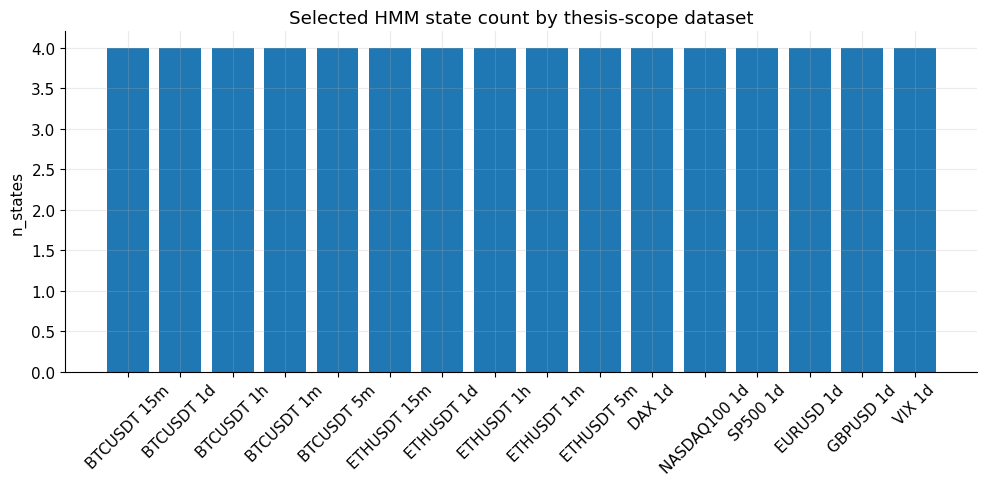

In [3]:
model_selection = loaded["hmm_model_selection"]
display_table(model_selection, 30)
save_table(model_selection, "study_regime_comparison_hmm_model_selection")

state_col = next((c for c in ["selected_n_states", "n_states", "states", "best_n_states"] if c in model_selection.columns), None)
if not model_selection.empty and state_col:
    label_cols = [c for c in ["asset", "frequency", "feature_set"] if c in model_selection.columns]
    labels = model_selection[label_cols].astype(str).agg(" ".join, axis=1) if label_cols else model_selection.index.astype(str)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(labels, model_selection[state_col])
    ax.set_title("Selected HMM state count by thesis-scope dataset")
    ax.set_ylabel(state_col)
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    save_fig(fig, "study_regime_comparison_hmm_selected_state_count", FIGURE_DIRS["regime_comparison"])
    plt.show()
else:
    print("HMM model-selection state column is not available.")


## HMM Posterior Confidence


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_hmm_confidence_histogram.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_hmm_confidence_histogram.pdf


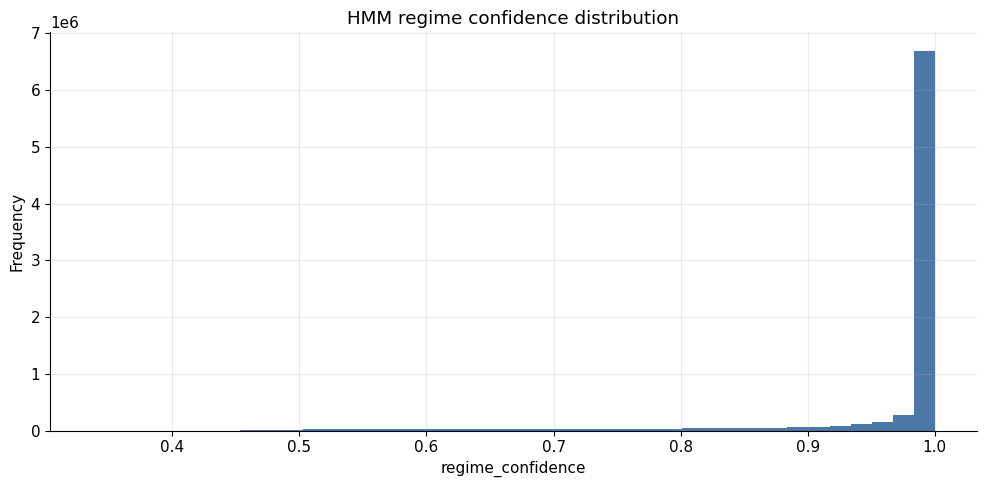

/tmp/ipykernel_2349667/2693773879.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels_order, showfliers=False)


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_hmm_confidence_by_regime.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_hmm_confidence_by_regime.pdf


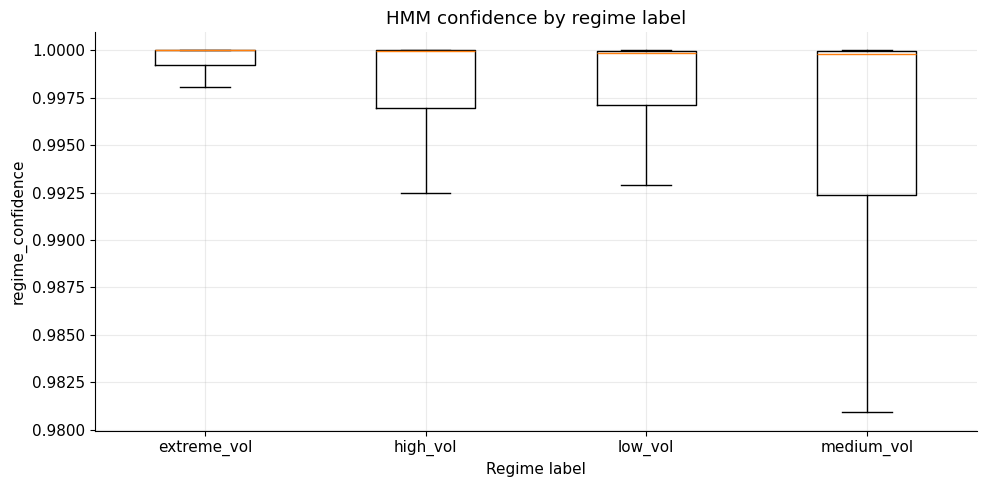

In [4]:
hmm_labels = loaded["hmm_labels"]
confidence_col = next((c for c in ["regime_confidence", "posterior_probability", "max_posterior", "confidence"] if c in hmm_labels.columns), None)
reg = regime_column(hmm_labels)
if hmm_labels.empty or not confidence_col:
    print("No HMM posterior confidence column is available.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    hmm_labels[confidence_col].dropna().plot(kind="hist", bins=40, ax=ax, color="#4C78A8")
    ax.set_title("HMM regime confidence distribution")
    ax.set_xlabel(confidence_col)
    fig.tight_layout()
    save_fig(fig, "study_regime_comparison_hmm_confidence_histogram", FIGURE_DIRS["regime_comparison"])
    plt.show()

    if reg:
        groups = [part[confidence_col].dropna().to_numpy() for _, part in hmm_labels.groupby(reg)]
        labels_order = [str(k) for k, _ in hmm_labels.groupby(reg)]
        if groups:
            fig, ax = plt.subplots(figsize=(10, 5))
            ax.boxplot(groups, labels=labels_order, showfliers=False)
            ax.set_title("HMM confidence by regime label")
            ax.set_xlabel("Regime label")
            ax.set_ylabel(confidence_col)
            fig.tight_layout()
            save_fig(fig, "study_regime_comparison_hmm_confidence_by_regime", FIGURE_DIRS["regime_comparison"])
            plt.show()


## ARI and NMI Evaluation


,asset,frequency,hmm_method,quantile_method,observations,adjusted_rand_index,normalized_mutual_information,sklearn_available
0,BTCUSDT,15m,hmm_4_states,quantile_2_rolling_240,210280,0.104907,0.101279,True
1,BTCUSDT,15m,hmm_4_states,quantile_2_rolling_30,210280,0.104907,0.101279,True
2,BTCUSDT,15m,hmm_4_states,quantile_2_rolling_60,210280,0.104907,0.101279,True
3,BTCUSDT,15m,hmm_4_states,quantile_3_rolling_240,210280,0.096696,0.108348,True
4,BTCUSDT,15m,hmm_4_states,quantile_3_rolling_30,210280,0.096696,0.108348,True
5,BTCUSDT,15m,hmm_4_states,quantile_3_rolling_60,210280,0.096696,0.108348,True
6,BTCUSDT,15m,hmm_4_states,quantile_4_rolling_240,210280,0.083035,0.107027,True
7,BTCUSDT,15m,hmm_4_states,quantile_4_rolling_30,210280,0.083035,0.107027,True
8,BTCUSDT,15m,hmm_4_states,quantile_4_rolling_60,210280,0.083035,0.107027,True
9,BTCUSDT,1d,hmm_4_states,quantile_2_rolling_240,2192,0.031602,0.032155,True


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_regime_comparison_ari_nmi.csv


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_adjusted_rand_index.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_adjusted_rand_index.pdf


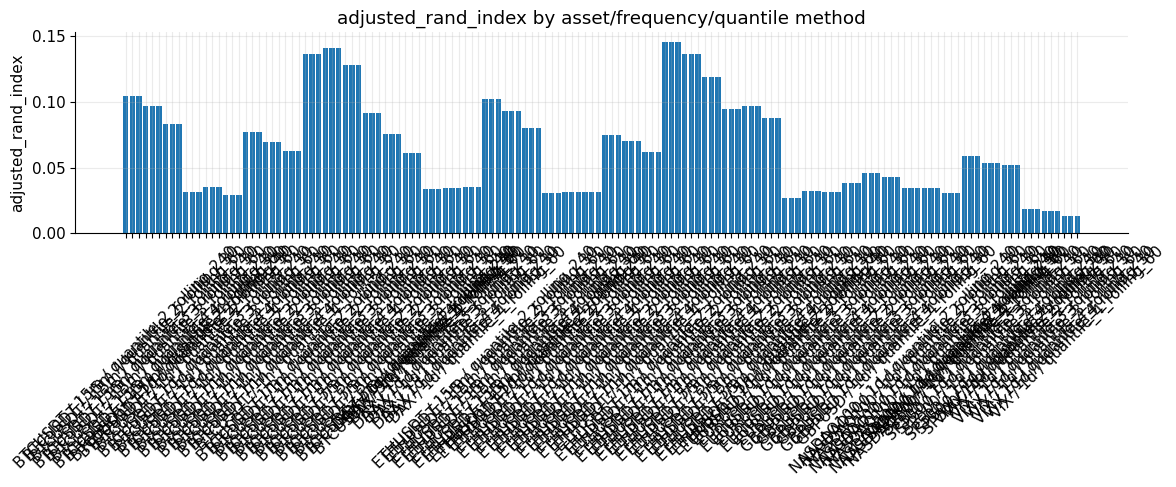

Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_normalized_mutual_information.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_normalized_mutual_information.pdf


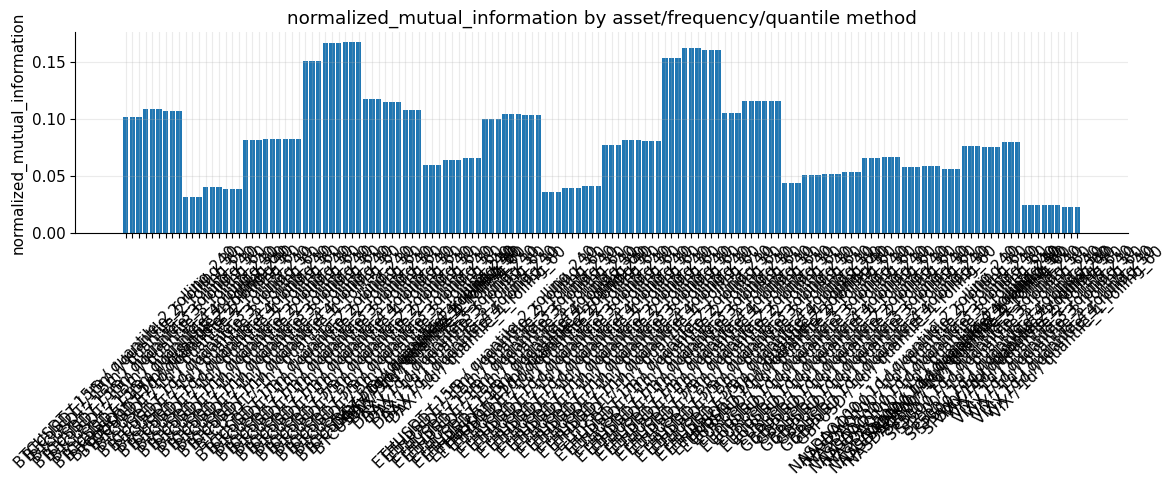

In [5]:
comparison = loaded["hmm_quantile_comparison"]
display_table(comparison, 30)
save_table(comparison, "study_regime_comparison_ari_nmi")

def plot_metric_bars(df, metric, filename):
    if df.empty or metric not in df.columns:
        print(f"{metric} is not available.")
        return
    label_cols = [c for c in ["asset", "frequency", "quantile_method", "regime_method"] if c in df.columns]
    labels = df[label_cols].astype(str).agg(" / ".join, axis=1) if label_cols else df.index.astype(str)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(labels, df[metric])
    ax.set_title(f"{metric} by asset/frequency/quantile method")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    save_fig(fig, filename, FIGURE_DIRS["regime_comparison"])
    plt.show()

ari_col = next((c for c in comparison.columns if c.lower() in ["adjusted_rand_index", "ari"]), None) if not comparison.empty else None
nmi_col = next((c for c in comparison.columns if c.lower() in ["normalized_mutual_information", "nmi"]), None) if not comparison.empty else None
if ari_col:
    plot_metric_bars(comparison, ari_col, "study_regime_comparison_adjusted_rand_index")
if nmi_col:
    plot_metric_bars(comparison, nmi_col, "study_regime_comparison_normalized_mutual_information")
if not ari_col and not nmi_col:
    print("ARI/NMI columns are not available in the comparison table.")


## Confusion Heatmaps


,asset,frequency,regime_method_hmm,regime_method_quantile,regime_label_hmm,regime_label_quantile,count
0,BTCUSDT,15m,hmm_4_states,quantile_2_rolling_240,extreme_vol,high_vol,1
1,BTCUSDT,15m,hmm_4_states,quantile_2_rolling_240,high_vol,high_vol,19997
2,BTCUSDT,15m,hmm_4_states,quantile_2_rolling_240,high_vol,low_vol,3218
3,BTCUSDT,15m,hmm_4_states,quantile_2_rolling_240,low_vol,high_vol,29636
4,BTCUSDT,15m,hmm_4_states,quantile_2_rolling_240,low_vol,low_vol,68825
5,BTCUSDT,15m,hmm_4_states,quantile_2_rolling_240,medium_vol,high_vol,55506
6,BTCUSDT,15m,hmm_4_states,quantile_2_rolling_240,medium_vol,low_vol,33097
7,BTCUSDT,15m,hmm_4_states,quantile_2_rolling_30,extreme_vol,high_vol,1
8,BTCUSDT,15m,hmm_4_states,quantile_2_rolling_30,high_vol,high_vol,19997
9,BTCUSDT,15m,hmm_4_states,quantile_2_rolling_30,high_vol,low_vol,3218


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_regime_comparison_confusion_table_raw.csv


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_confusion_BTCUSDT_15m.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_confusion_BTCUSDT_15m.pdf


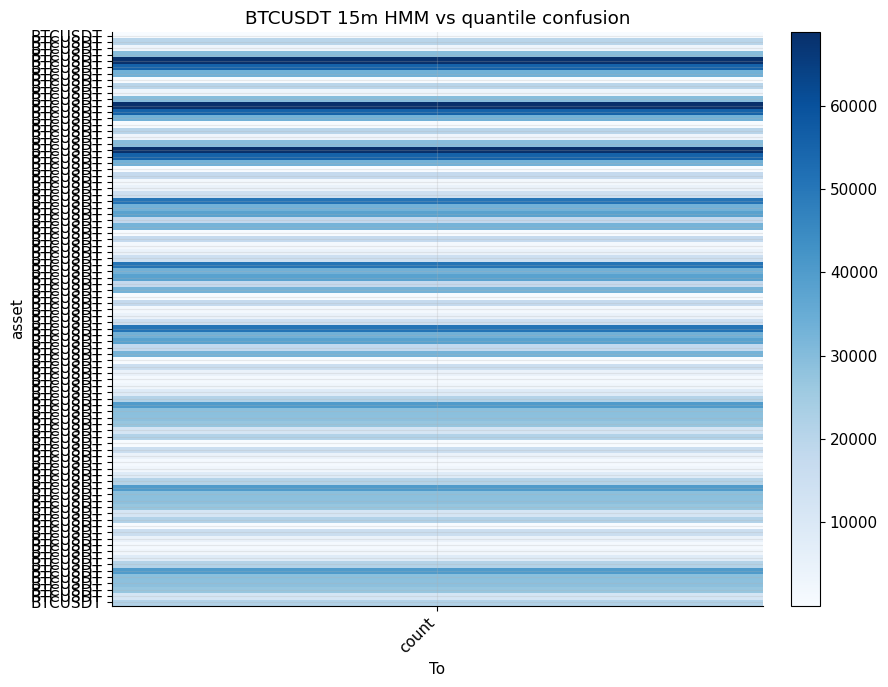

Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_confusion_BTCUSDT_1h.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_confusion_BTCUSDT_1h.pdf


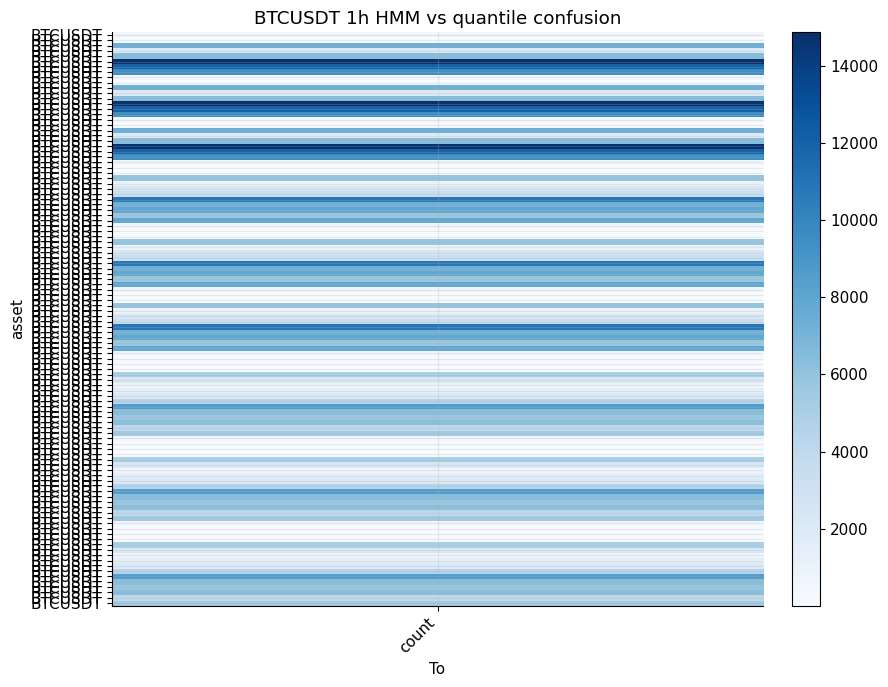

Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_confusion_ETHUSDT_15m.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_confusion_ETHUSDT_15m.pdf


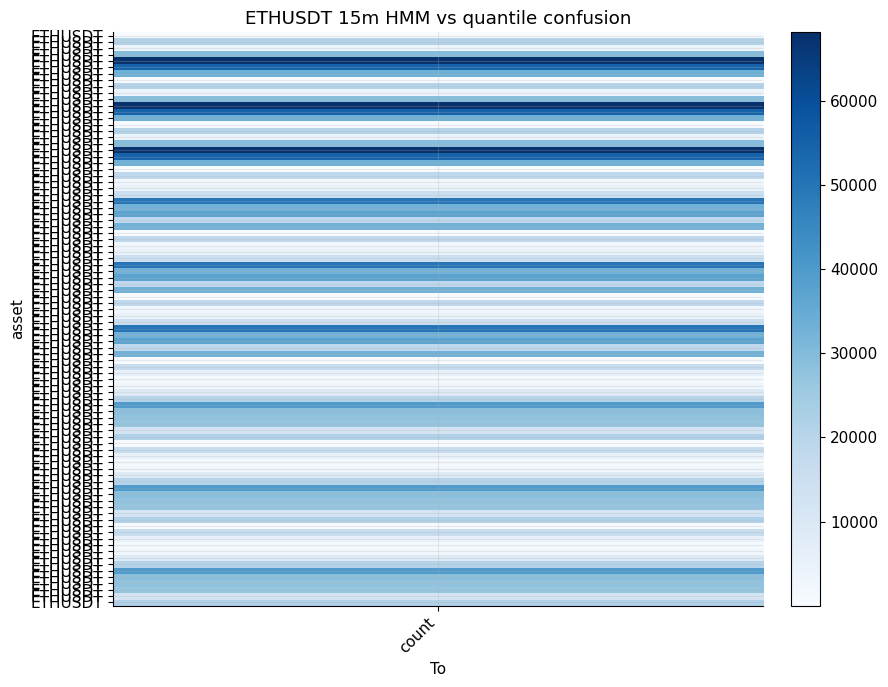

Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_confusion_ETHUSDT_1h.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_confusion_ETHUSDT_1h.pdf


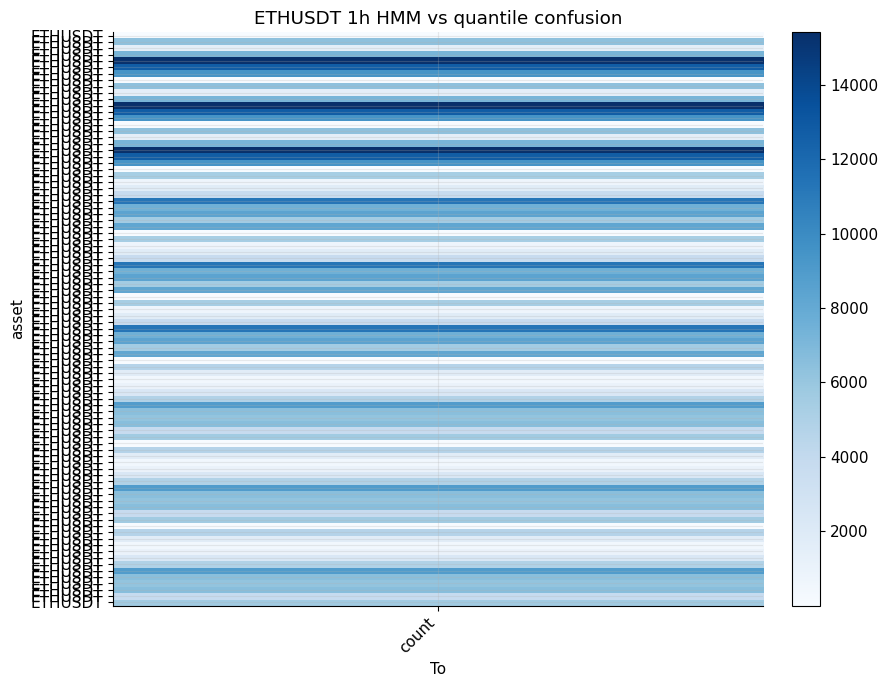

In [6]:
confusion = loaded["hmm_quantile_confusion"]
display_table(confusion, 20)
save_table(confusion, "study_regime_comparison_confusion_table_raw")

for asset in THESIS_SCOPE_ASSETS:
    for frequency in THESIS_SCOPE_FREQUENCIES:
        filters = {"asset": asset, "frequency": frequency}
        if "quantile_method" in confusion.columns:
            methods = confusion["quantile_method"].dropna().astype(str).unique()
            preferred = "quantile_2_rolling_240"
            filters["quantile_method"] = preferred if preferred in methods else (methods[0] if len(methods) else preferred)
        plot_heatmap_from_table(
            confusion,
            f"{asset} {frequency} HMM vs quantile confusion",
            f"study_regime_comparison_confusion_{asset}_{frequency}",
            FIGURE_DIRS["regime_comparison"],
            filters,
        )


## Regime Persistence Comparison


,method_family,asset,frequency,regime_method,regime_label,self_transition_probability
0,quantile,BTCUSDT,15m,quantile_2_rolling_30,high_vol,0.988786
1,quantile,BTCUSDT,15m,quantile_2_rolling_30,low_vol,0.988786
2,quantile,BTCUSDT,15m,quantile_3_rolling_30,high_vol,0.985577
3,quantile,BTCUSDT,15m,quantile_3_rolling_30,low_vol,0.984192
4,quantile,BTCUSDT,15m,quantile_3_rolling_30,medium_vol,0.970197
5,quantile,BTCUSDT,15m,quantile_4_rolling_30,extreme_vol,0.983603
6,quantile,BTCUSDT,15m,quantile_4_rolling_30,low_vol,0.982823
7,quantile,BTCUSDT,15m,quantile_4_rolling_30,high_vol,0.962051
8,quantile,BTCUSDT,15m,quantile_4_rolling_30,medium_vol,0.961138
9,quantile,BTCUSDT,15m,quantile_2_rolling_60,high_vol,0.988786


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_regime_comparison_self_transition_probabilities.csv


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_self_transition_probabilities.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/regime_comparison/study_regime_comparison_self_transition_probabilities.pdf


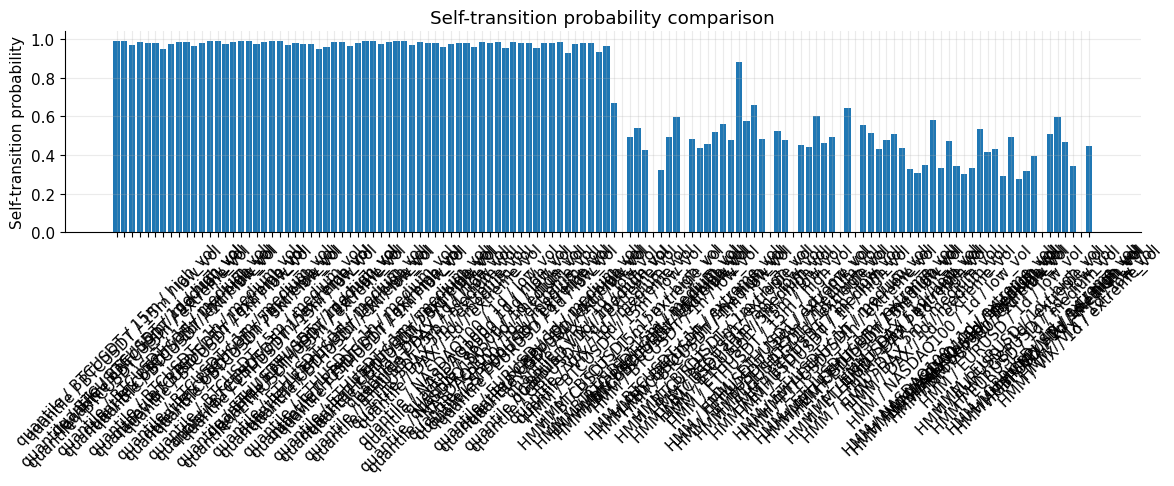

In [7]:
def extract_self_transition(df, method_family):
    if df is None or df.empty:
        return pd.DataFrame()
    work = df.copy()
    from_col = next((c for c in ["from_regime", "source_regime", "regime_from"] if c in work.columns), None)
    to_col = next((c for c in ["to_regime", "target_regime", "regime_to"] if c in work.columns), None)
    prob_col = next((c for c in ["self_transition_probability", "probability", "transition_probability"] if c in work.columns and pd.api.types.is_numeric_dtype(work[c])), None)
    if "self_transition_probability" in work.columns:
        out = work.copy()
        out["self_transition_probability"] = out["self_transition_probability"]
    elif from_col and to_col and prob_col:
        out = work[work[from_col].astype(str) == work[to_col].astype(str)].copy()
        out["self_transition_probability"] = out[prob_col]
        out["regime_label"] = out[from_col]
    else:
        return pd.DataFrame()
    out["method_family"] = method_family
    keep = [c for c in ["method_family", "asset", "frequency", "regime_method", "regime_label", "self_transition_probability"] if c in out.columns]
    return out[keep]

self_transitions = pd.concat([
    extract_self_transition(loaded["quantile_transitions"], "quantile"),
    extract_self_transition(loaded["hmm_persistence"], "HMM"),
], ignore_index=True)
display_table(self_transitions, 30)
save_table(self_transitions, "study_regime_comparison_self_transition_probabilities")

if not self_transitions.empty and "self_transition_probability" in self_transitions.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    labels = self_transitions[[c for c in ["method_family", "asset", "frequency", "regime_label"] if c in self_transitions.columns]].astype(str).agg(" / ".join, axis=1)
    ax.bar(labels, self_transitions["self_transition_probability"])
    ax.set_title("Self-transition probability comparison")
    ax.set_ylabel("Self-transition probability")
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    save_fig(fig, "study_regime_comparison_self_transition_probabilities", FIGURE_DIRS["regime_comparison"])
    plt.show()
else:
    print("Self-transition probabilities could not be inferred from available files.")


## Key findings
Quantile and HMM comparisons should be read from the ARI, NMI, confusion, confidence, and persistence tables above when available.

## Thesis-safe interpretation
Quantile and HMM regimes do not need to match exactly. Their disagreement is informative because quantile regimes partition observed volatility directly, while HMM regimes infer latent states from multiple features. For motif discovery, both provide alternative market-state partitions under nonstationarity.

## Limitations
Empty comparison or confusion tables mean no numerical alignment claim should be made from this notebook. Missing confidence columns mean posterior-confidence figures cannot be reported.

## Recommended figures for thesis
- HMM selected state count
- HMM confidence histogram if posterior columns are available
- ARI and NMI bar charts if comparison rows are available
- HMM-vs-quantile confusion heatmaps when the confusion table is populated
